<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML_Internship_Sep_Oct_2025_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

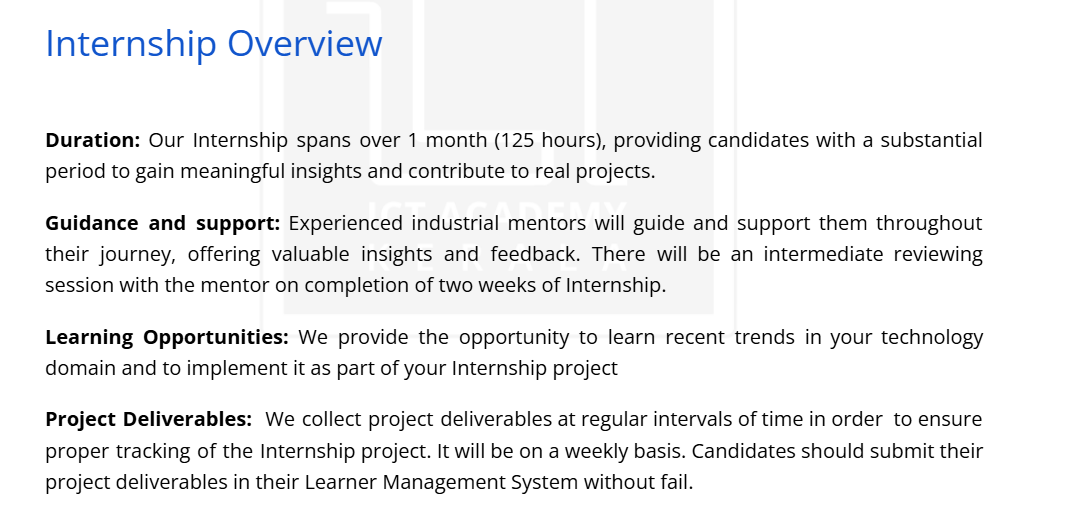

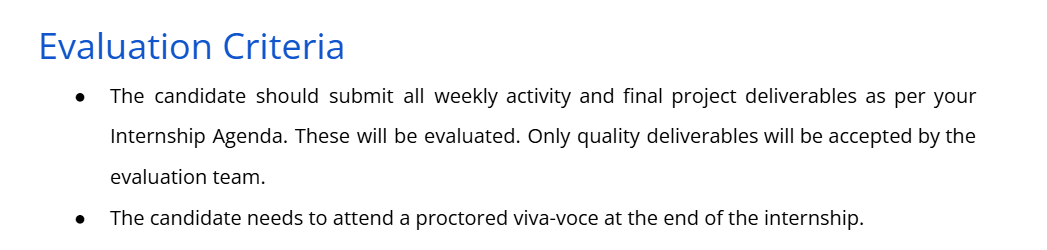

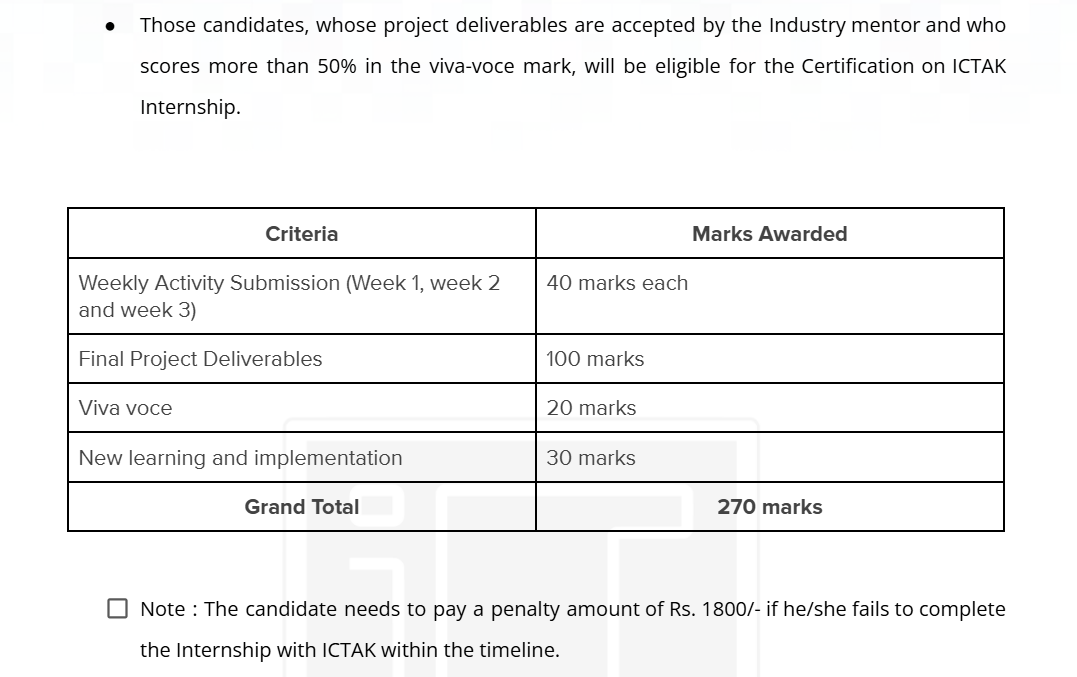

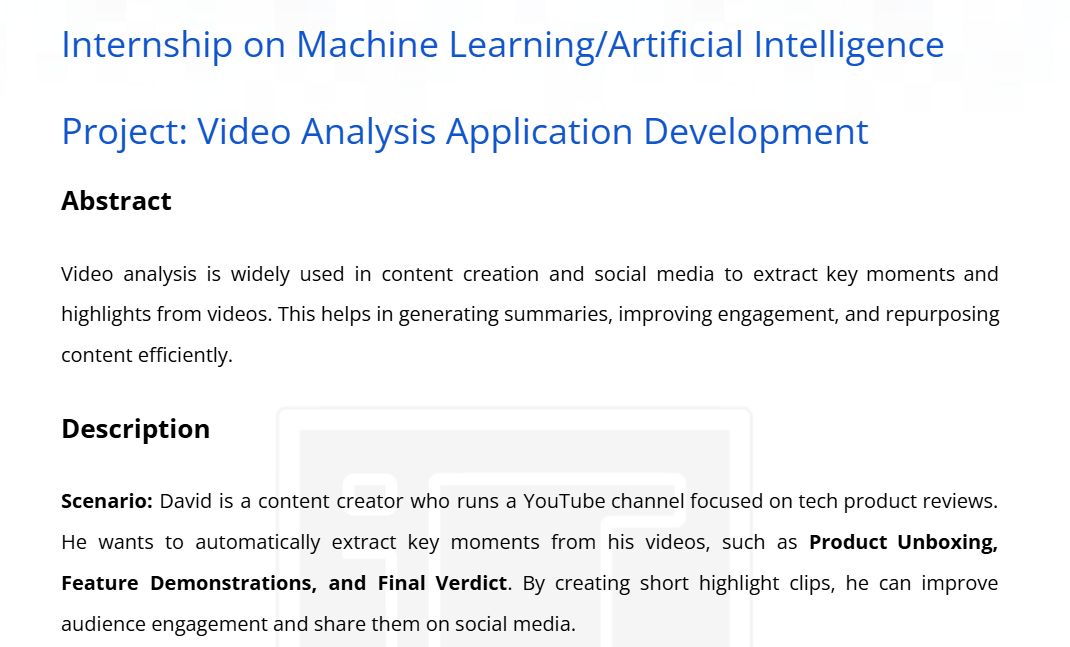

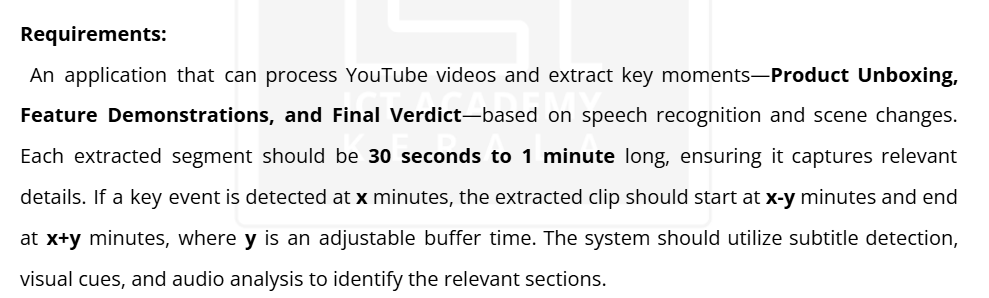

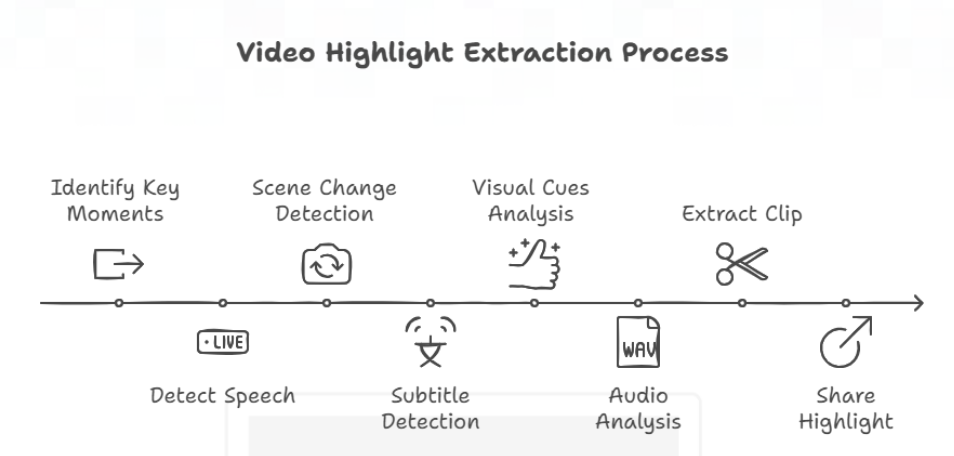

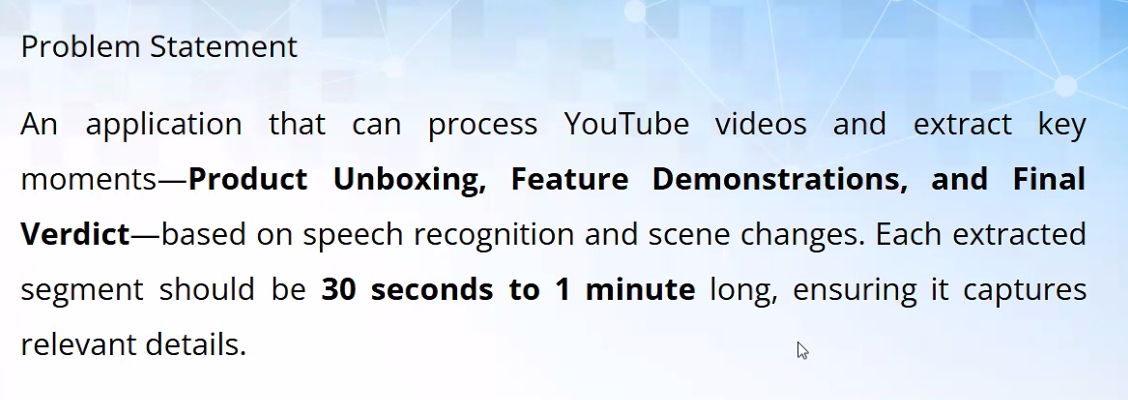

https://www.analyticsvidhya.com/blog/2019/09/step-by-step-deep-learning-tutorial-video-classification-python/

https://www.analyticsvidhya.com/blog/2024/02/metas-v-jepa-revolutionizing-video-understanding-in-ai/

https://medium.com/@sand.mayur/building-an-ai-video-analysis-agent-a-journey-into-multimodal-intelligence-c9c7c543d8d8

### 1. downloader.py — Download YouTube video + subtitles

Save as downloader.py

video link:https://www.youtube.com/watch?v=bh6LdziZpYo

---

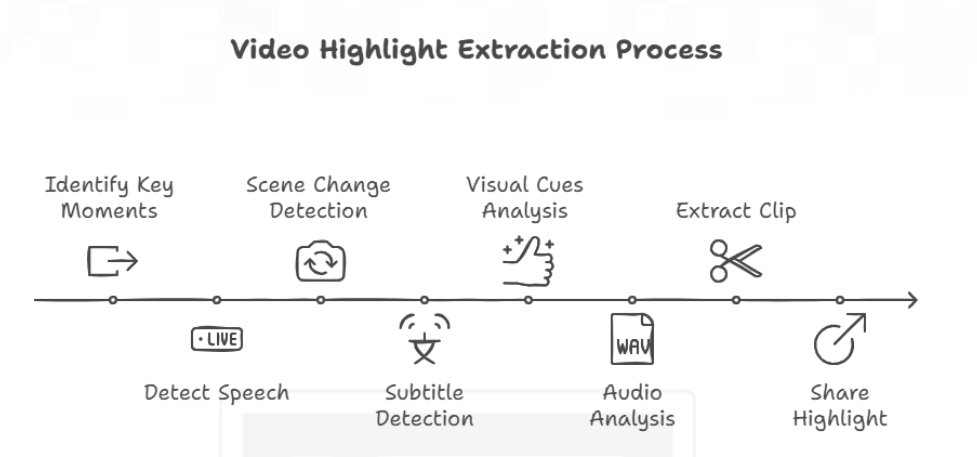

# **Speech Detection**

## python code to upload a video in google colab and detect speech

1. Upload a video file (.mp4, .mkv, etc.)
2. Extract its audio
3. Transcribe (detect speech) using OpenAI Whisper (or Google Speech Recognition as a fallback).

### Step 1 — Set up Colab environment

Run this cell first in Google Colab:

In [ ]:
# Install required libraries
!pip install moviepy openai-whisper

### Step 2 — Upload your video

This code lets you upload any local video into the Colab session:

In [ ]:
from google.colab import files

print("📤 Upload your video file (.mp4, .mkv, etc.)")
uploaded = files.upload()  # Opens a file picker

# Get the uploaded filename
video_path = list(uploaded.keys())[0]
print("✅ Uploaded:", video_path)


📤 Upload your video file (.mp4, .mkv, etc.)


Saving Apple Watch Series 10 UNBOXING and REVIEW _ Worth It(1).mp4 to Apple Watch Series 10 UNBOXING and REVIEW _ Worth It(1) (1).mp4
✅ Uploaded: Apple Watch Series 10 UNBOXING and REVIEW _ Worth It(1) (1).mp4


### Step 3 — Extract audio from the video

We’ll use moviepy to get just the audio track.

In [ ]:
from moviepy.editor import VideoFileClip

# Extract audio
clip = VideoFileClip(video_path)
audio_path = "extracted_audio.wav"
clip.audio.write_audiofile(audio_path)

print("🎧 Audio extracted:", audio_path)


MoviePy - Writing audio in extracted_audio.wav


MoviePy - Done.
🎧 Audio extracted: extracted_audio.wav


### Step 4 — Detect speech (transcribe audio)

Using OpenAI Whisper (works fully offline in Colab):

In [ ]:
import whisper

# Load the Whisper model (you can use "tiny", "base", "small", "medium", "large")
model = whisper.load_model("base")

# Transcribe audio
print("🔍 Transcribing...")
result = model.transcribe(audio_path)

# Print transcript
print("\n📝 Transcription:\n")
print(result["text"])


  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



🔍 Transcribing...

📝 Transcription:

 So it's the brand new Apple Watch series 10. Honestly, I was hoping for like a limited edition or new series like X, you know how they do for a 10 year anniversary. But still series 10, 10 years of Apple Watch, absolutely crazy, the most popular and the best selling fitness watch like ever, hands down like period. Like Apple Watch could be like its own separate company and still crush it, still make you know, lots of lots of money. But quickly we'll do a unboxing. So you can see the actual design. It's still the same kind of thinness, Apple's Quest for carbon neutrality in 2030. They've kept it, you know, super slim. The little butterfly switches which I like and you can see the watch up top. So obviously we're greeted with a brand new watch face. I've seen some of them before and they do look pretty good. And underneath, since I did get this in just standard aluminum, this one comes with just a Velcro sport loop. And the thing that I love about Ap

# **Scene change detection**

### Step 1 — Install dependencies

Run this cell first in Colab:

In [ ]:
!pip install scenedetect[opencv] moviepy

### Step 2 — Upload your video

This code lets you upload a local video (e.g. .mp4, .mkv, .avi):

In [ ]:
from google.colab import files

print("📤 Upload your video file")
uploaded = files.upload()  # Opens file picker
video_path = list(uploaded.keys())[0]
print("✅ Uploaded:", video_path)


📤 Upload your video file


Saving Apple Watch Series 10 UNBOXING and REVIEW _ Worth It(1).mp4 to Apple Watch Series 10 UNBOXING and REVIEW _ Worth It(1) (2).mp4
✅ Uploaded: Apple Watch Series 10 UNBOXING and REVIEW _ Worth It(1) (2).mp4


### Step 3 — Detect scene changes

We’ll use the content detector, which finds cuts based on changes in color or intensity between frames.

In [ ]:
from scenedetect import VideoManager, SceneManager
from scenedetect.detectors import ContentDetector

# Create video & scene managers
video_manager = VideoManager([video_path])
scene_manager = SceneManager()
scene_manager.add_detector(ContentDetector(threshold=30.0))  # threshold can be tuned

# Start video manager and perform detection
video_manager.start()
scene_manager.detect_scenes(frame_source=video_manager)

# Get list of detected scenes
scene_list = scene_manager.get_scene_list()
print(f"🎞️ Detected {len(scene_list)} scene(s):\n")

for i, scene in enumerate(scene_list):
    start, end = scene
    print(f"Scene {i+1}: Start = {start.get_timecode()}, End = {end.get_timecode()}")


ERROR:pyscenedetect:VideoManager is deprecated and will be removed.
INFO:pyscenedetect:Loaded 1 video, framerate: 29.970 FPS, resolution: 640 x 360
INFO:pyscenedetect:Detecting scenes...


🎞️ Detected 122 scene(s):

Scene 1: Start = 00:00:00.000, End = 00:00:01.802
Scene 2: Start = 00:00:01.802, End = 00:00:02.836
Scene 3: Start = 00:00:02.836, End = 00:00:05.072
Scene 4: Start = 00:00:05.072, End = 00:00:09.309
Scene 5: Start = 00:00:09.309, End = 00:00:11.078
Scene 6: Start = 00:00:11.078, End = 00:00:12.379
Scene 7: Start = 00:00:12.379, End = 00:00:14.548
Scene 8: Start = 00:00:14.548, End = 00:00:16.550
Scene 9: Start = 00:00:16.550, End = 00:00:19.219
Scene 10: Start = 00:00:19.219, End = 00:00:23.690
Scene 11: Start = 00:00:23.690, End = 00:00:26.994
Scene 12: Start = 00:00:26.994, End = 00:00:28.862
Scene 13: Start = 00:00:28.862, End = 00:00:30.931
Scene 14: Start = 00:00:30.931, End = 00:00:33.600
Scene 15: Start = 00:00:33.600, End = 00:00:35.535
Scene 16: Start = 00:00:35.535, End = 00:00:37.771
Scene 17: Start = 00:00:37.771, End = 00:00:38.305
Scene 18: Start = 00:00:38.305, End = 00:00:43.977
Scene 19: Start = 00:00:43.977, End = 00:00:45.145
Scene 20: Sta

### Step 4 — (Optional) Save each scene as a separate clip

If you want to save each scene as a separate video file, run:

In [ ]:
from scenedetect.video_splitter import split_video_ffmpeg

# Split video into scenes
split_video_ffmpeg([video_path], scene_list, output_dir='scenes', video_name='scene')


ERROR:pyscenedetect:Using a list of paths is deprecated. Pass a single path instead.
INFO:pyscenedetect:Splitting video with ffmpeg, output path template:
  $VIDEO_NAME-Scene-$SCENE_NUMBER.mp4
INFO:pyscenedetect:Output folder:
  $VIDEO_NAME-Scene-$SCENE_NUMBER.mp4


0

# **Subtitle detection**

- 1️ Extract embedded subtitle tracks (if the video already has .srt or .vtt inside it).
- 2️⃣ Generate subtitles from speech (speech-to-text using a model like OpenAI Whisper).

Let’s go through both options.

### Step 1 — Install Dependencies

Run this in a Colab cell first:

In [ ]:
!pip install ffmpeg-python whisper openai-whisper

### Step 2 — Upload Your Video

Use this code to upload a video file (e.g., .mp4, .mkv, .avi):

In [ ]:
from google.colab import files

print("📤 Upload your video file")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print("✅ Uploaded:", video_path)


📤 Upload your video file


Saving Apple Watch Series 10 UNBOXING and REVIEW _ Worth It(1).mp4 to Apple Watch Series 10 UNBOXING and REVIEW _ Worth It(1) (3).mp4
✅ Uploaded: Apple Watch Series 10 UNBOXING and REVIEW _ Worth It(1) (3).mp4


# OPTION 1: Extract Existing Subtitles (if present)

If the video already has subtitles embedded (common in .mkv or YouTube downloads):

In [ ]:
import ffmpeg
import os

output_sub = "extracted_subs.srt"

try:
    (
        ffmpeg
        .input(video_path)
        .output(output_sub, **{'map': '0:s:0'})  # Extract first subtitle stream
        .run(overwrite_output=True, quiet=True)
    )
    if os.path.exists(output_sub):
        print(f"✅ Subtitle extracted and saved as: {output_sub}")
    else:
        print("⚠️ No subtitles found in the video.")
except ffmpeg.Error as e:
    print("❌ Error extracting subtitles:", e)


❌ Error extracting subtitles: ffmpeg error (see stderr output for detail)


### OPTION 2: Auto-Generate Subtitles using Whisper (Speech-to-Text)

If your video has no subtitle track, we can use OpenAI’s Whisper model to automatically detect speech and create subtitles.

In [ ]:
import whisper

# Load the small model (you can use "base", "small", "medium", "large")
model = whisper.load_model("small")

print("🔊 Transcribing speech to text...")
result = model.transcribe(video_path)

# Save as an .srt file
srt_path = "auto_subtitles.srt"
with open(srt_path, "w", encoding="utf-8") as f:
    for i, segment in enumerate(result["segments"], start=1):
        start = segment["start"]
        end = segment["end"]
        text = segment["text"].strip()
        f.write(f"{i}\n")
        f.write(f"{int(start//3600):02}:{int((start%3600)//60):02}:{int(start%60):02},000 --> {int(end//3600):02}:{int((end%3600)//60):02}:{int(end%60):02},000\n")
        f.write(f"{text}\n\n")

print(f"✅ Auto-generated subtitles saved as: {srt_path}")


100%|███████████████████████████████████████| 461M/461M [00:07<00:00, 68.9MiB/s]
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")



🔊 Transcribing speech to text...
✅ Auto-generated subtitles saved as: auto_subtitles.srt


# **visual cues analysis**

### Step 1 — Install Dependencies

Run this first in a Colab cell:

In [ ]:
!pip install opencv-python matplotlib


### Step 2 — Perform Visual Cue Analysis

We’ll analyze:

- Scene changes using frame difference

- Brightness variation

- Dominant color changes

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Open video file
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise IOError("Cannot open video")

frame_diffs = []
brightness_vals = []
color_means = []
prev_frame = None

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    brightness_vals.append(np.mean(gray))

    # Dominant color (mean of each channel)
    color_means.append(np.mean(frame, axis=(0, 1)))

    # Scene change detection using frame difference
    if prev_frame is not None:
        diff = cv2.absdiff(gray, prev_frame)
        frame_diffs.append(np.mean(diff))
    prev_frame = gray
    frame_idx += 1

cap.release()

frame_diffs = np.array(frame_diffs)
brightness_vals = np.array(brightness_vals)
color_means = np.array(color_means)

# Normalize frame diff values for plotting
norm_diffs = (frame_diffs - frame_diffs.min()) / (frame_diffs.max() - frame_diffs.min())

# Estimate scene changes where difference > threshold
scene_change_indices = np.where(norm_diffs > 0.4)[0]
print("🟩 Scene changes detected at frames:", scene_change_indices)


🟩 Scene changes detected at frames: [  151   370   435   495   575   709   926  1006  1131  1317  1352  1728
  1833  1908  2089  2121  2560  2625  2699  2912  3047  3151  3380  3500
  3718  3839  3879  4052  4144  4192  4356  4506  4984  5032  5588  5679
  6260  6408  6581  6920  8169  8353  8486  8692  8917  9010  9188  9324
  9748  9841 10060 10232 10359 10448 10672 10768 10842 10962 11013 11095
 11255 11432 12117 12183 12896 12979]


### Step 3 — Plot Visual Cue Trends

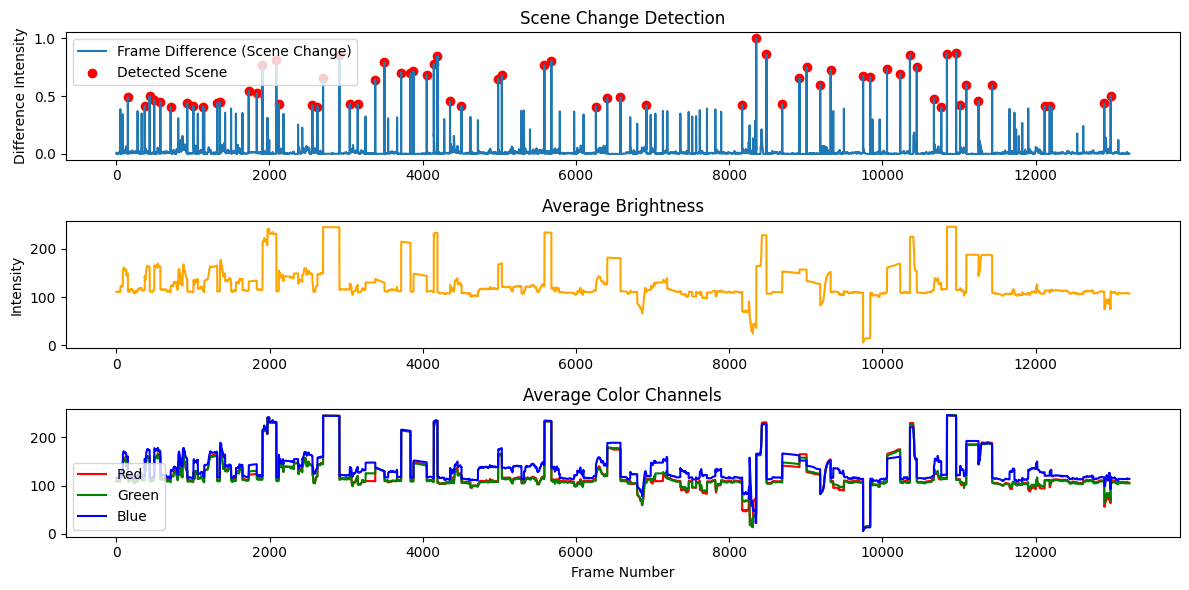

In [ ]:
frames = np.arange(len(brightness_vals))

plt.figure(figsize=(12, 6))

plt.subplot(3,1,1)
plt.plot(frames[1:], norm_diffs, label='Frame Difference (Scene Change)')
plt.scatter(scene_change_indices, norm_diffs[scene_change_indices], color='r', label='Detected Scene')
plt.legend(); plt.title("Scene Change Detection"); plt.ylabel("Difference Intensity")

plt.subplot(3,1,2)
plt.plot(frames, brightness_vals, color='orange')
plt.title("Average Brightness"); plt.ylabel("Intensity")

plt.subplot(3,1,3)
plt.plot(frames, color_means[:,0], 'r', label='Red')
plt.plot(frames, color_means[:,1], 'g', label='Green')
plt.plot(frames, color_means[:,2], 'b', label='Blue')
plt.legend(); plt.title("Average Color Channels"); plt.xlabel("Frame Number")

plt.tight_layout()
plt.show()


# **Audio Analysis**

### Step 1 — Install Required Libraries

Run this cell first:

In [ ]:
!pip install librosa matplotlib numpy soundfile

### Step 2 — Load Audio and Visualize the Waveform

  fig.canvas.print_figure(bytes_io, **kw)



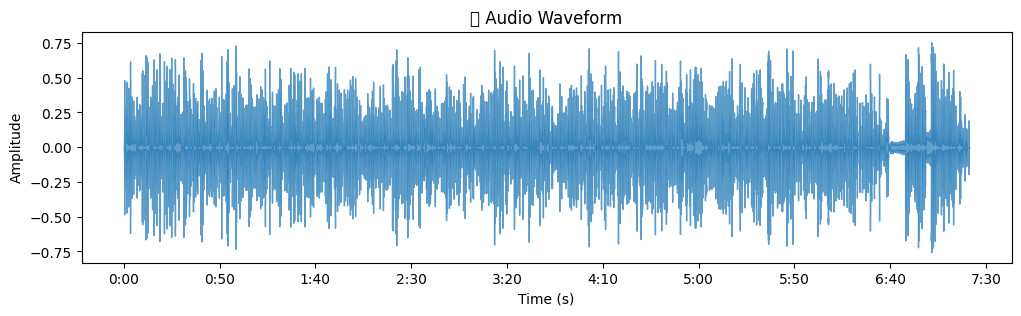

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Load audio
audio_data, sr = librosa.load(audio_path, sr=None)

plt.figure(figsize=(12, 3))
librosa.display.waveshow(audio_data, sr=sr, alpha=0.7)
plt.title("🎵 Audio Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()


### Step 3 — Volume (Energy) & Silence Detection

This step measures short-term energy (helps find loud vs silent regions).

  fig.canvas.print_figure(bytes_io, **kw)



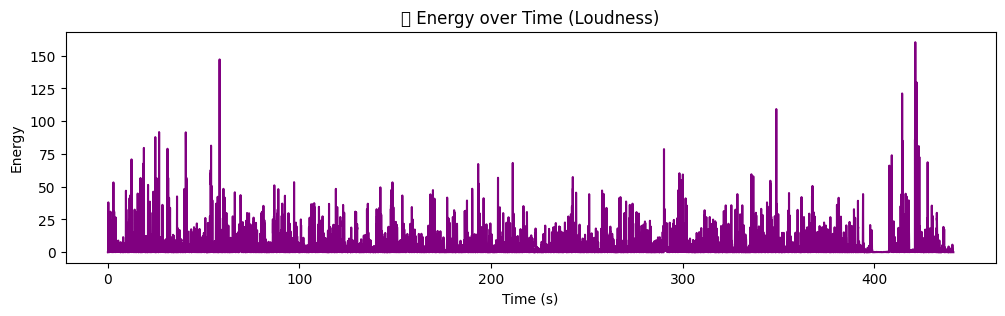

🗣️ Detected speech frames: 18667


In [ ]:
import numpy as np

frame_length = 2048
hop_length = 512
energy = np.array([
    sum(abs(audio_data[i:i+frame_length]**2))
    for i in range(0, len(audio_data), hop_length)
])

times = np.arange(len(energy)) * hop_length / sr

plt.figure(figsize=(12, 3))
plt.plot(times, energy, color='purple')
plt.title("🔊 Energy over Time (Loudness)")
plt.xlabel("Time (s)")
plt.ylabel("Energy")
plt.show()

# Optional: Detect silence
threshold = np.mean(energy) * 0.3
speech_segments = np.where(energy > threshold)[0]
print("🗣️ Detected speech frames:", len(speech_segments))


### Step 4 — Pitch and Spectrogram Analysis

  fig.canvas.print_figure(bytes_io, **kw)



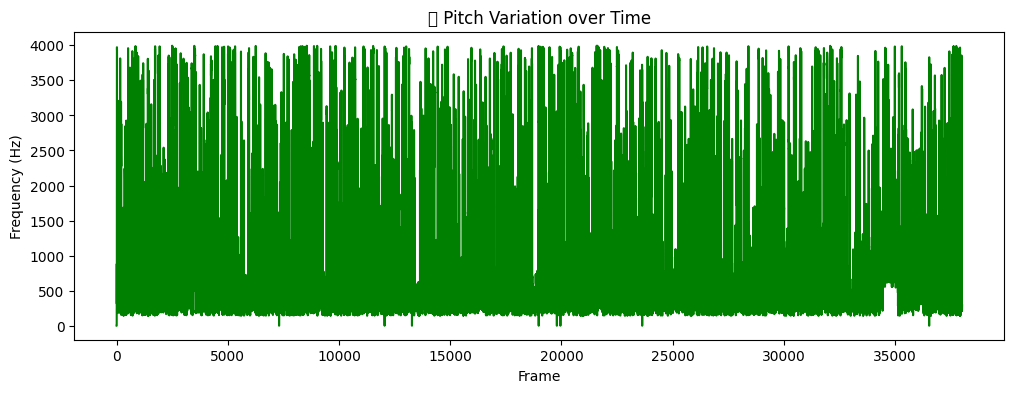

  fig.canvas.print_figure(bytes_io, **kw)



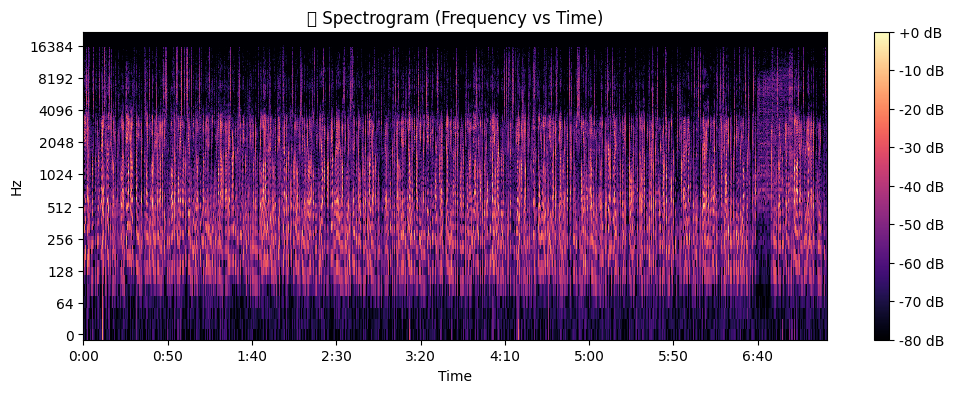

In [ ]:
# Compute pitch and spectrogram
spectrogram = np.abs(librosa.stft(audio_data))
pitch, mag = librosa.piptrack(y=audio_data, sr=sr)

# Average pitch over time
pitches = []
for i in range(pitch.shape[1]):
    index = mag[:, i].argmax()
    pitches.append(pitch[index, i])

plt.figure(figsize=(12, 4))
plt.plot(pitches, color='green')
plt.title("🎶 Pitch Variation over Time")
plt.xlabel("Frame")
plt.ylabel("Frequency (Hz)")
plt.show()

# Display spectrogram
plt.figure(figsize=(12, 4))
librosa.display.specshow(librosa.amplitude_to_db(spectrogram, ref=np.max),
                         sr=sr, x_axis='time', y_axis='log', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("🎧 Spectrogram (Frequency vs Time)")
plt.show()


### Step 5 — Extract Basic Audio Features

In [ ]:
features = {
    "Zero Crossing Rate": np.mean(librosa.feature.zero_crossing_rate(y=audio_data)),
    "Spectral Centroid": np.mean(librosa.feature.spectral_centroid(y=audio_data, sr=sr)),
    "Spectral Bandwidth": np.mean(librosa.feature.spectral_bandwidth(y=audio_data, sr=sr)),
    "Spectral Contrast": np.mean(librosa.feature.spectral_contrast(y=audio_data, sr=sr)),
    "RMSE (Energy)": np.mean(librosa.feature.rms(y=audio_data))
}

for k, v in features.items():
    print(f"{k:25s}: {v:.3f}")


Zero Crossing Rate       : 0.088
Spectral Centroid        : 2807.149
Spectral Bandwidth       : 2525.255
Spectral Contrast        : 19.783
RMSE (Energy)            : 0.035
